Taken From https://towardsdatascience.com/how-to-cluster-images-based-on-visual-similarity-cd6e7209fe34
Uses pre-trained VGG16 CNN

In [ ]:
!pip install keras

In [ ]:
# for loading/processing the images
import tensorflow
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input

# models
from keras.applications.vgg16 import VGG16
from keras.models import Model

# clustering and dimension reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# for everything else
import os
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import pandas as pd
import pickle
from PIL import Image

In [ ]:
# import csv of imagej analyzed data
df = pd.read_csv("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/=7-6_analysis_CSV.csv")
flowers = np.array(df["File_Name"])
len(flowers)

2835

In [ ]:
# # load the image as a 224x224 array
# img = load_img("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/Tiffs/" +
#                flowers[0]+".tif", target_size=(224,224))
# # convert from 'PIL.Image.Image' to numpy array
# img = np.array(img)

# print(img.shape)

# reshaped_img = img.reshape(1,224,224,3)
# print(reshaped_img.shape)
# x = preprocess_input(reshaped_img)

In [ ]:
# # load model
# model = VGG16()
# # remove the output layer
# model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
flowers

array(['Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075',
       'Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425',
       'Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21', ...,
       'Ga=0.21,Gi=0.12,Ua=0.037,Ui=0.045',
       'Ga=0.21,Gi=0.12,Ua=0.037,Ui=0.1425',
       'Ga=0.21,Gi=0.12,Ua=0.037,Ui=0.24'], dtype=object)

In [ ]:
#all in one fxn
model = VGG16()
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

def extract_features(file, model):
    # load the image as a 224x224 array
    img = load_img("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/Tiffs/" +
               file +".tif", target_size=(224,224))
    # convert from 'PIL.Image.Image' to numpy array
    img = np.array(img)
    # reshape the data for the model reshape(num_of_samples, dim 1, dim 2, channels)
    reshaped_img = img.reshape(1,224,224,3)
    # prepare image for model
    imgx = preprocess_input(reshaped_img)
    # get the feature vector
    features = model.predict(imgx, use_multiprocessing=True)
    return features

553467096/553467096 [==============================] - 9s 0us/step


In [ ]:
data = {}
# p = r"E:\Documents\My Projects\Instagram Dashboard\Model Development\flower_features.pkl"

# lop through each image in the dataset
for flower in flowers:
    # try to extract the features and update the dictionary
    # try:
      feat = extract_features(flower,model)
      data[flower] = feat
    # if something fails, save the extracted features as a pickle file (optional)
    # except:
    #     with open(p,'wb') as file:
    #         pickle.dump(data,file)


# get a list of the filenames
# filenames = np.array(list(data.keys()))

# get a list of just the features
# feat = np.array(list(data.values()))
# feat.shape
# (210, 1, 4096)

# reshape so that there are 210 samples of 4096 vectors
# feat = feat.reshape(-1,4096)
# feat.shape
# (210, 4096)

# # get the unique labels (from the flower_labels.csv)
# df = pd.read_csv('flower_labels.csv')
# label = df['label'].tolist()
# unique_labels = list(set(label))

In [ ]:
#saving data structutre (image features)
pickle_out = open("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/Data_Pickle_7-20.pkl","wb")
pickle.dump(data, pickle_out)
pickle_out.close()

In [ ]:
#load image features saved as pickle file
with open('/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/Data_Pickle_7-20.pkl', 'rb') as f:

    data = pickle.load(f) # deserialize using load()
    print(data) # print student names

In [ ]:
# get a list of the filenames
filenames = np.array(list(data.keys()))

# get a list of just the features
feat = np.array(list(data.values()))
feat.shape
(210, 1, 4096)

# reshape so that there are 210 samples of 4096 vectors
feat = feat.reshape(-1,4096)
feat.shape
(210, 4096)

# # get the unique labels (from the flower_labels.csv) we already have the labels as filenames
# df = pd.read_csv('flower_labels.csv')
# label = df['label'].tolist()
# unique_labels = list(set(label))




(210, 4096)

In [ ]:
#Dimensionality Reduction
pca = PCA(n_components=100, random_state=22)
pca.fit(feat)
x = pca.transform(feat)

In [ ]:
#saving data structute (PCA image features)
pickle_out = open("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/PCA_Data_Pickle_7-20.pkl","wb")
pickle.dump(x, pickle_out)
pickle_out.close()

In [ ]:
#Analysis of PCA effectiveness
print(pca.explained_variance_ratio_) #shows the variance explained by each PC
print(sum(pca.explained_variance_ratio_))

[3.7675864e-01 1.3998811e-01 8.6009175e-02 6.0561944e-02 4.3089014e-02
 3.4338854e-02 2.4312699e-02 2.2597402e-02 1.5203454e-02 1.4020175e-02
 1.2481549e-02 1.1494374e-02 9.4278380e-03 8.1514399e-03 6.9869477e-03
 6.4334949e-03 5.8724675e-03 5.4547405e-03 5.0721001e-03 5.0639044e-03
 4.4002039e-03 4.1993125e-03 3.5397585e-03 3.3822085e-03 3.2111157e-03
 2.9881559e-03 2.8414596e-03 2.8063736e-03 2.6725137e-03 2.5303871e-03
 2.3535450e-03 2.2057048e-03 2.0339990e-03 1.8125258e-03 1.7998563e-03
 1.6196885e-03 1.5269985e-03 1.4455543e-03 1.3773676e-03 1.3315594e-03
 1.2880892e-03 1.2433347e-03 1.1713691e-03 1.1041402e-03 1.0682199e-03
 1.0570423e-03 1.0279969e-03 9.6756377e-04 9.5486315e-04 8.8495220e-04
 8.7588164e-04 8.2606374e-04 8.1002590e-04 8.0564542e-04 7.8710169e-04
 7.5756927e-04 7.1596680e-04 6.7864114e-04 6.7318085e-04 6.4512587e-04
 6.1437802e-04 5.8947981e-04 5.7622883e-04 5.5681402e-04 5.4218440e-04
 5.3443428e-04 5.3174846e-04 5.1820528e-04 5.1123113e-04 4.9849675e-04
 4.806

In [ ]:
# Kmeans fitting

kmeans = KMeans(
    init="random",
    n_clusters=3,
    n_init=10,
    max_iter=300,
    random_state=22
)

kmeans.fit(x)


KMeans(init='random', n_clusters=3, n_init=10, random_state=22)

In [ ]:
df["cluster"] = kmeans.labels_
df.head()

,File_Name,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster
0,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075",79.2727,724.0,0.326225,1.126500e-08,0.000523,0.713834,0.291812,1
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",224.3437,1.0,0.923225,2.308062e-05,0.000000,0.541700,0.000000,1
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",241.8883,1.0,0.995425,2.488562e-05,0.000000,0.760000,0.000000,1
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",239.9686,1.0,0.987525,2.468813e-05,0.000000,0.739200,0.000000,1
4,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.07135",135.4482,74.0,0.557400,1.883110e-07,0.060858,0.842827,0.243896,1


In [ ]:
#create dictionary of images in each cluster

uni_cat = np.array(df["cluster"])
uni_cat = np.unique(uni_cat)

cluster_dic = {}
for i in range(len(uni_cat)):
  cluster_dic[i] = []


for j in range(len(df["cluster"])):
  cluster_dic[(df["cluster"][j])].append(df["File_Name"][j])

for k in cluster_dic.keys(): #print the size of each cluster
  print(k,len(cluster_dic[k]))


0 998
1 538
2 1299


In [ ]:
#visualize images in each cluster
# white is intensity, black is background
k = 0
for j in cluster_dic[2]:
  if k < 100: #show the first 10 images in cluster
    print(j)
    img = Image.open("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/Tiffs/"
      +str(j) + ".tif" )
    img.show()
    k += 1
  else:
    break

In [ ]:
#dataframe for each cluster
df1 = df.loc[df["cluster"] == 0]
df2 = df.loc[df["cluster"] == 1]
df3 = df.loc[df["cluster"] == 2]



df1


,File_Name,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster
90,"Ba=-0.038,Da=0.0065,Di=0.5,Ga=0.075",110.0350,127.0,0.605925,1.192770e-07,0.002708,0.871239,0.140589,0
94,"Ba=-0.038,Da=0.0065,Di=0.5,Gi=0.07135",208.1649,1.0,0.935375,2.338438e-05,0.000000,0.634300,0.000000,0
95,"Ba=-0.038,Da=0.0065,Di=0.5,Gi=0.12",121.7546,113.0,0.651675,1.441760e-07,0.003838,0.858868,0.146410,0
98,"Ba=-0.038,Da=0.0065,Di=0.5,Ua=0.037",70.0394,163.0,0.470300,7.213200e-08,0.001249,0.911640,0.096980,0
99,"Ba=-0.038,Da=0.0065,Di=0.5,Ui=0.045",63.0322,171.0,0.388900,5.685700e-08,0.000797,0.976649,0.055712,0
...,...,...,...,...,...,...,...,...,...
2805,"Ga=0.1425,Gi=0.12,Ua=0.037,Ui=0.045",10.6096,57.0,0.082625,3.623900e-08,0.000325,0.987667,0.048769,0
2806,"Ga=0.1425,Gi=0.12,Ua=0.037,Ui=0.1425",150.3420,3.0,0.873525,7.279375e-06,0.390457,0.450733,0.251698,0
2823,"Ga=0.21,Gi=0.07135,Ua=0.037,Ui=0.045",76.1858,19.0,0.463650,6.100660e-07,0.011357,0.552984,0.168485,0
2829,"Ga=0.21,Gi=0.12,Ua=0.02265,Ui=0.045",110.8884,68.0,0.602850,2.216360e-07,0.011460,0.726782,0.249009,0


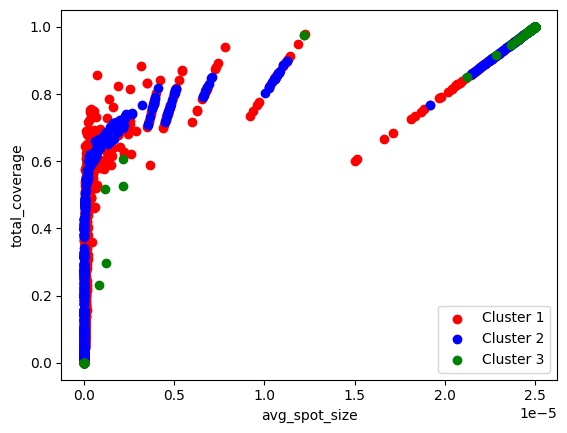

In [ ]:
from matplotlib import style
#plotting clustering against parameters
fig2 = plt.figure()
ax = plt.axes()

x = "avg_spot_size" #set x and y to plot different params and features
y = "total_coverage"

# xdata = df[x]
# ydata = df[y]
# # zdata = df["component_3"]
# colors = df["cluster"]

ax.set_xlabel(x)
ax.set_ylabel(y)
# ax.set_zlabel('C3')

# ax.view_init(45, 45)
ax.scatter(df1[x], df1[y], c="red", label = "Cluster 1")
ax.scatter(df2[x],df2[y],c="blue", label = "Cluster 2")
ax.scatter(df3[x],df3[y],c="green", label = "Cluster 3")
ax.legend()
# ax.view_init(45, 45)
plt.style.use('default')
plt.show()


In [ ]:
from mpl_toolkits import mplot3d
#3d Plot
fig = plt.figure()
ax = plt.axes(projection='3d')

x = "avg_spot_size"
y = "avg_circ"
z = "num_spots"

xdata = df[x]
ydata = df[y]
zdata = df[z]
colors = df["cluster"]

ax.set_xlabel(x)
ax.set_ylabel(y)
ax.set_zlabel(z)



ax.scatter3D(xdata, ydata, zdata, c=colors)
ax.view_init(0, 90)
plt.show()

In [ ]:
df.to_csv("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/df_7-20-23.csv")